### Nhóm 2
### Demo Self-Organizing Maps (SOM)
Nội dung bao gồm:
- Dataset: Phân khúc khách hàng (CC GENERAL)
- Khảo sát dữ liệu & thống kê nhanh
- Tiền xử lý & chuẩn hóa
- Xây dựng SOM và huấn luyện
- Trực quan (U-Matrix, hit map)
- Gom cụm trên SOM và so sánh, đánh giá
- Lưu mô hình

In [46]:
## Thư viện
import time
import joblib as jlb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sbn
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import MinMaxScaler

sbn.set_style('whitegrid')

### Đọc dữ liệu phân khúc khách hàng

In [47]:
## Đọc dữ liệu
data = pd.read_csv('Data/CC GENERAL.csv')
print('** 5 dòng đầu của dữ liệu:')
print(data.head())
print(f'** Số dòng: {data.shape[0]}, số cột: {data.shape[1]}')

** 5 dòng đầu của dữ liệu:
  CUST_ID      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0  C10001    40.900749           0.818182      95.40              0.00   
1  C10002  3202.467416           0.909091       0.00              0.00   
2  C10003  2495.148862           1.000000     773.17            773.17   
3  C10004  1666.670542           0.636364    1499.00           1499.00   
4  C10005   817.714335           1.000000      16.00             16.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                    95.4      0.000000             0.166667   
1                     0.0   6442.945483             0.000000   
2                     0.0      0.000000             1.000000   
3                     0.0    205.788017             0.083333   
4                     0.0      0.000000             0.083333   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                    0.000000                          0.083333   
1        

In [48]:
## Thông tin và giá trị thiếu
print('** Thông tin dữ liệu:')
data.info()

missing = data.isna().sum().sort_values(ascending=False)
print('** Thiếu giá trị (top 10):')
print(missing.head(10))

** Thông tin dữ liệu:
<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  


In [49]:
## Thống kê nhanh
print('** Thống kê nhanh (top 10 cột):')
print(data.describe().T.head(10))

** Thống kê nhanh (top 10 cột):
                                   count         mean          std  min  \
BALANCE                           8950.0  1564.474828  2081.531879  0.0   
BALANCE_FREQUENCY                 8950.0     0.877271     0.236904  0.0   
PURCHASES                         8950.0  1003.204834  2136.634782  0.0   
ONEOFF_PURCHASES                  8950.0   592.437371  1659.887917  0.0   
INSTALLMENTS_PURCHASES            8950.0   411.067645   904.338115  0.0   
CASH_ADVANCE                      8950.0   978.871112  2097.163877  0.0   
PURCHASES_FREQUENCY               8950.0     0.490351     0.401371  0.0   
ONEOFF_PURCHASES_FREQUENCY        8950.0     0.202458     0.298336  0.0   
PURCHASES_INSTALLMENTS_FREQUENCY  8950.0     0.364437     0.397448  0.0   
CASH_ADVANCE_FREQUENCY            8950.0     0.135144     0.200121  0.0   

                                         25%         50%          75%  \
BALANCE                           128.281915  873.385231  2054.140036


### Tiền xử lý và chuẩn hóa


In [50]:
## Loại bỏ cột ID và xử lý missing
data_clean = data.drop(columns=['CUST_ID'])
missing_before = data_clean.isna().sum().sum()
data_clean = data_clean.fillna(data_clean.median(numeric_only=True))
missing_after = data_clean.isna().sum().sum()

print(f'** Thiếu trước: {missing_before}, sau: {missing_after}')

## Chuẩn hóa về [0, 1]
scaler = MinMaxScaler()
X = scaler.fit_transform(data_clean)
print('** Kích thước X:', X.shape)

** Thiếu trước: 314, sau: 0
** Kích thước X: (8950, 17)



### Xây dựng SOM

In [51]:
## SOM đơn giản (không cần thư viện bên ngoài)
class SimpleSOM:
    def __init__(self, m, n, dim, lr=0.5, sigma=None, seed=42):
        self.m = m
        self.n = n
        self.dim = dim
        self.lr = lr
        self.sigma = sigma if sigma is not None else max(m, n) / 2
        self.rng = np.random.default_rng(seed)
        self.weights = self.rng.random((m, n, dim))

    def _decay(self, value, t, max_iter):
        return value * np.exp(-t / max_iter)

    def bmu(self, x):
        diff = self.weights - x
        dist = np.linalg.norm(diff, axis=2)
        idx = np.unravel_index(np.argmin(dist), dist.shape)
        return idx

    def train(self, data, num_iter=2000):
        for t in range(num_iter):
            x = data[self.rng.integers(0, data.shape[0])]
            bmu = self.bmu(x)

            lr_t = self._decay(self.lr, t, num_iter)
            sigma_t = self._decay(self.sigma, t, num_iter)

            for i in range(self.m):
                for j in range(self.n):
                    dist_sq = (i - bmu[0]) ** 2 + (j - bmu[1]) ** 2
                    influence = np.exp(-dist_sq / (2 * (sigma_t ** 2)))
                    self.weights[i, j] += influence * lr_t * (x - self.weights[i, j])

    def distance_map(self):
        um = np.zeros((self.m, self.n))
        for i in range(self.m):
            for j in range(self.n):
                neighbors = []
                for di in (-1, 0, 1):
                    for dj in (-1, 0, 1):
                        if di == 0 and dj == 0:
                            continue
                        ni, nj = i + di, j + dj
                        if 0 <= ni < self.m and 0 <= nj < self.n:
                            neighbors.append(self.weights[ni, nj])
                if neighbors:
                    d = np.linalg.norm(self.weights[i, j] - np.array(neighbors), axis=1)
                    um[i, j] = d.mean()
        return um

In [52]:
## Huấn luyện SOM
som = SimpleSOM(m=10, n=10, dim=X.shape[1], lr=0.5, sigma=None, seed=42)
som.train(X, num_iter=3000)
print('** SOM đã được huấn luyện. Lưới: 10x10')

** SOM đã được huấn luyện. Lưới: 10x10


### Trực quan SOM

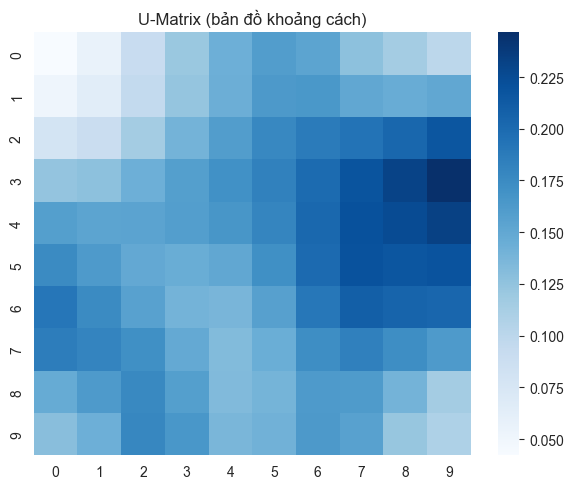

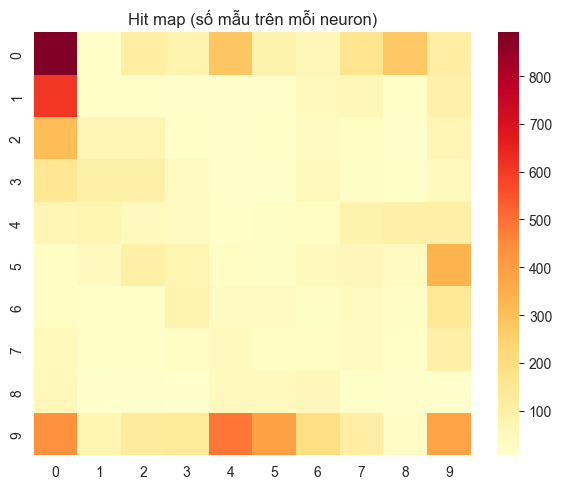

In [53]:
## Bản đồ U-Matrix
u_matrix = som.distance_map()
plt.figure(figsize=(6, 5))
sbn.heatmap(u_matrix, cmap='Blues')
plt.title('U-Matrix (bản đồ khoảng cách)')
plt.tight_layout()
plt.savefig('Output/som_u_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Bản đồ hit
hits = np.zeros((som.m, som.n), dtype=int)
for x in X:
    i, j = som.bmu(x)
    hits[i, j] += 1
plt.figure(figsize=(6, 5))
sbn.heatmap(hits, cmap='YlOrRd')
plt.title('Hit map (số mẫu trên mỗi neuron)')
plt.tight_layout()
plt.savefig('Output/som_hit_map.png', dpi=150, bbox_inches='tight')
plt.show()

### Gom cụm trên SOM & đánh giá nhanh

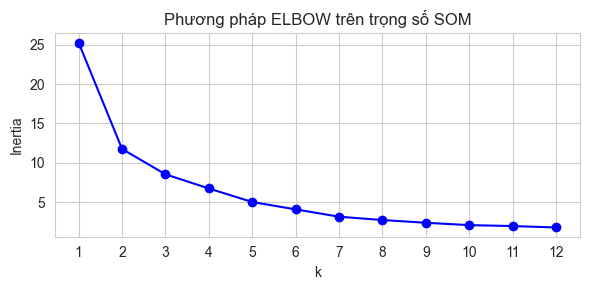

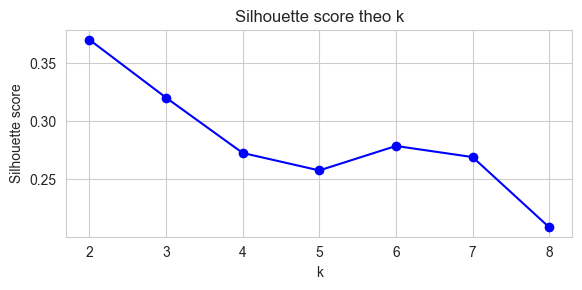

** Số cụm tốt nhất (theo Silhouette): 2
** Kích thước cluster:
cluster
0    4465
1    4485
Name: count, dtype: int64
** Trung bình theo cluster (top 8 cột):
         BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
cluster                                                            
0        1421.10               0.93    1741.89            965.32   
1        1707.21               0.82     267.81            221.21   

         INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
cluster                                                              
0                        777.08        578.80                 0.86   
1                         46.68       1377.16                 0.13   

         ONEOFF_PURCHASES_FREQUENCY  
cluster                              
0                              0.33  
1                              0.08  


In [54]:
## Gom cụm trên SOM bằng KMeans trên trọng số
def som_cluster_labels(som, X, k):
    weight_vectors = som.weights.reshape(-1, som.dim)
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(weight_vectors)
    weight_labels = kmeans.labels_.reshape(som.m, som.n)

    labels = np.array([weight_labels[som.bmu(x)] for x in X])
    return labels, kmeans, weight_labels

## Đánh giá số cụm bằng phương pháp ELBOW
weight_vectors = som.weights.reshape(-1, som.dim)
nb_clusters_elbow = range(1, 13)
inertias = []

for k in nb_clusters_elbow:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(weight_vectors)
    inertias.append(model.inertia_)

plt.figure(figsize=(6, 3))
plt.plot(nb_clusters_elbow, inertias, 'bo-')
plt.xlabel('k')
plt.xticks(list(nb_clusters_elbow))
plt.ylabel('Inertia')
plt.title('Phương pháp ELBOW trên trọng số SOM')
plt.tight_layout()
plt.savefig('Output/som_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

## Đánh giá nhanh bằng Silhouette
nb_clusters = range(2, 9)
scores = []
for k in nb_clusters:
    labels_k, _, _ = som_cluster_labels(som, X, k)
    score = silhouette_score(X, labels_k, metric='euclidean')
    scores.append(score)

plt.figure(figsize=(6, 3))
plt.plot(nb_clusters, scores, 'bo-')
plt.xlabel('k')
plt.xticks(list(nb_clusters))
plt.ylabel('Silhouette score')
plt.title('Silhouette score theo k')
plt.tight_layout()
plt.savefig('Output/som_silhouette_scan.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = nb_clusters[int(np.argmax(scores))]
print(f'** Số cụm tốt nhất (theo Silhouette): {best_k}')

labels, kmeans, weight_labels = som_cluster_labels(som, X, best_k)
data_cluster = data_clean.copy()
data_cluster['cluster'] = labels

print('** Kích thước cluster:')
print(data_cluster['cluster'].value_counts().sort_index())

print('** Trung bình theo cluster (top 8 cột):')
cluster_profile = data_cluster.groupby('cluster').mean().round(2).iloc[:, :8]
print(cluster_profile)
cluster_profile.to_csv('Output/som_cluster_profile.csv')
data_cluster.to_csv('Output/som_cluster_labels.csv', index=False)

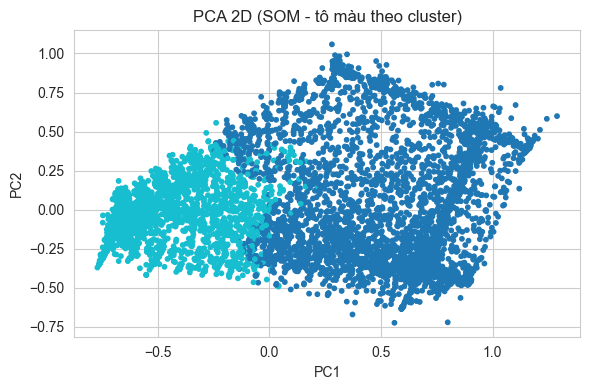

In [55]:
## Biểu diễn dữ liệu trên không gian PCA (SOM)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(6, 4))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', s=10)
plt.title('PCA 2D (SOM - tô màu theo cluster)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.savefig('Output/som_pca_2d.png', dpi=150, bbox_inches='tight')
plt.show()

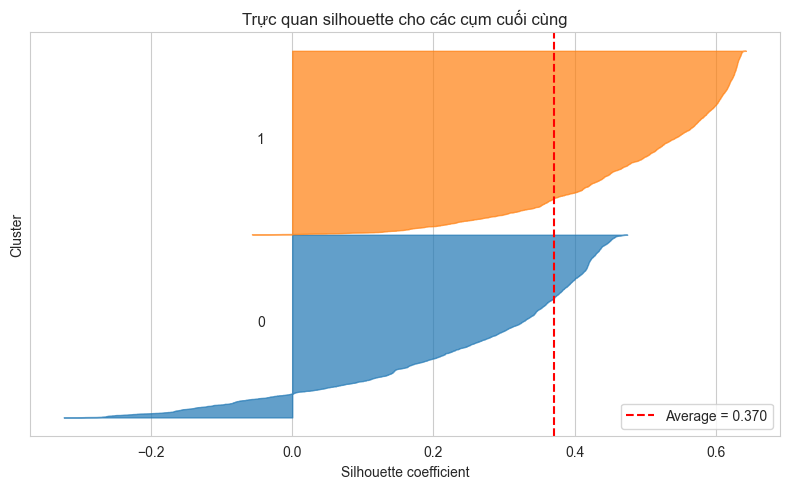

In [56]:
## Trực quan silhouette cho các cụm cuối cùng
sample_silhouette_values = silhouette_samples(X, labels, metric='euclidean')
silhouette_avg = silhouette_score(X, labels, metric='euclidean')
n_clusters = len(np.unique(labels))

plt.figure(figsize=(8, 5))
y_lower = 10
for cluster_id in range(n_clusters):
    cluster_values = sample_silhouette_values[labels == cluster_id]
    cluster_values.sort()
    size_cluster = cluster_values.shape[0]
    y_upper = y_lower + size_cluster
    color = plt.cm.tab10(cluster_id % 10)
    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_values,
        facecolor=color,
        edgecolor=color,
        alpha=0.7
    )
    plt.text(-0.05, y_lower + 0.5 * size_cluster, str(cluster_id))
    y_lower = y_upper + 10

plt.axvline(x=silhouette_avg, color='red', linestyle='--', label=f'Average = {silhouette_avg:.3f}')
plt.title('Trực quan silhouette cho các cụm cuối cùng')
plt.xlabel('Silhouette coefficient')
plt.ylabel('Cluster')
plt.yticks([])
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('Output/som_silhouette_detail.png', dpi=150, bbox_inches='tight')
plt.show()

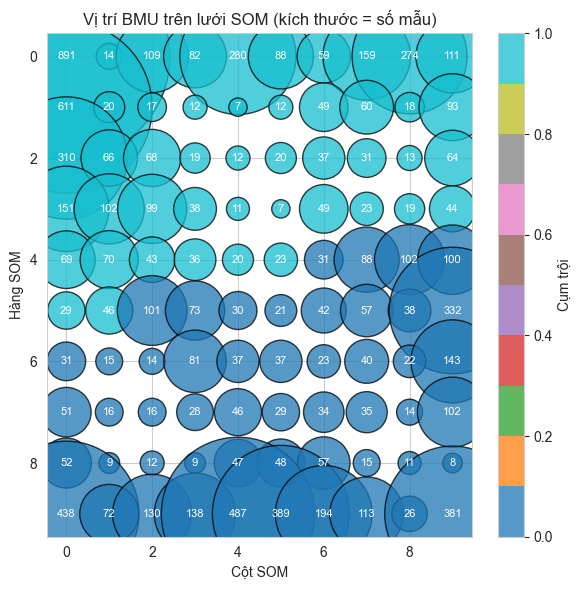

In [57]:
## Biểu diễn vị trí BMU trên lưới SOM
bmu_coords = np.array([som.bmu(sample) for sample in X])
bmu_frame = pd.DataFrame({
    'row': bmu_coords[:, 0],
    'col': bmu_coords[:, 1],
    'cluster': labels
})
bmu_summary = (
    bmu_frame.groupby(['row', 'col'], as_index=False)
    .agg(count=('cluster', 'size'), dominant_cluster=('cluster', lambda s: s.value_counts().idxmax()))
)

plt.figure(figsize=(6, 6))
scatter = plt.scatter(
    bmu_summary['col'],
    bmu_summary['row'],
    s=bmu_summary['count'] * 25,
    c=bmu_summary['dominant_cluster'],
    cmap='tab10',
    alpha=0.75,
    edgecolors='black'
)
for _, row in bmu_summary.iterrows():
    plt.text(row['col'], row['row'], int(row['count']), ha='center', va='center', fontsize=8, color='white')
plt.gca().invert_yaxis()
plt.colorbar(scatter, label='Cụm trội')
plt.title('Vị trí BMU trên lưới SOM (kích thước = số mẫu)')
plt.xlabel('Cột SOM')
plt.ylabel('Hàng SOM')
plt.tight_layout()
plt.savefig('Output/som_bmu_map.png', dpi=150, bbox_inches='tight')
plt.show()


### So sánh Self Organizing Maps với Kmeans và DBSCAN

Saved Output/kmeans_metrics.csv
  algorithm params  n_clusters  silhouette  calinski_harabasz  davies_bouldin  \
0    KMeans    k=2           2    0.386742        6191.000866        1.111859   
1    KMeans    k=3           3    0.372394        4596.062677        1.321467   
2    KMeans    k=4           4    0.321510        3954.506135        1.423585   
3    KMeans    k=5           5    0.319125        3629.726482        1.303796   
4    KMeans    k=6           6    0.334222        3383.792856        1.208741   

   runtime_s  
0   0.089087  
1   0.075830  
2   0.110494  
3   0.123327  
4   0.136561  
Best KMeans by silhouette:
algorithm                 KMeans
params                       k=2
n_clusters                     2
silhouette              0.386742
calinski_harabasz    6191.000866
davies_bouldin          1.111859
runtime_s               0.089087
Name: 0, dtype: object


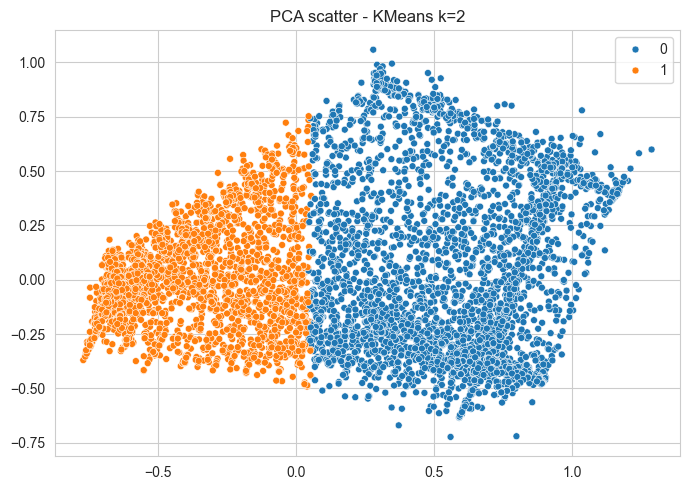

In [58]:
# KMeans
results_kmeans = []

for k in range(2, 7):
    t0 = time.time()
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    t1 = time.time()
    labels_km = km.labels_

    try:
        sil = silhouette_score(X, labels_km)
    except Exception:
        sil = float('nan')

    ch = calinski_harabasz_score(X, labels_km) if len(set(labels_km)) > 1 else float('nan')
    dbs = davies_bouldin_score(X, labels_km) if len(set(labels_km)) > 1 else float('nan')

    results_kmeans.append({
        'algorithm': 'KMeans',
        'params': f'k={k}',
        'n_clusters': len(set(labels_km)),
        'silhouette': sil,
        'calinski_harabasz': ch,
        'davies_bouldin': dbs,
        'runtime_s': t1 - t0,
    })

kmeans_df = pd.DataFrame(results_kmeans)
kmeans_df.to_csv('Output/kmeans_metrics.csv', index=False)
print('Saved Output/kmeans_metrics.csv')
print(kmeans_df)

best_km_row = kmeans_df.loc[kmeans_df['silhouette'].idxmax()]
print('Best KMeans by silhouette:')
print(best_km_row)

best_k = int(best_km_row['params'].split('=')[1])
best_km_labels = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit_predict(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(7, 5))
sbn.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=best_km_labels, palette='tab10', s=25, legend='full')
plt.title(f'PCA scatter - KMeans k={best_k}')
plt.tight_layout()
plt.savefig('Output/compare_best_KMeans.png', dpi=150, bbox_inches='tight')
plt.show()

Saved Output/dbscan_metrics.csv
  algorithm    params  n_clusters  silhouette  calinski_harabasz  \
0    DBSCAN  eps=0.03          55    0.444151        4865.969426   
1    DBSCAN  eps=0.05          85    0.292445        2404.670426   
2    DBSCAN  eps=0.08         105    0.092797         708.276773   
3    DBSCAN   eps=0.1          62   -0.257786          73.255413   

   davies_bouldin  runtime_s  
0        0.546089   0.590039  
1        0.902844   0.244593  
2        1.011106   0.460253  
3        1.201079   0.198660  
Best DBSCAN by silhouette:
algorithm                 DBSCAN
params                  eps=0.03
n_clusters                    55
silhouette              0.444151
calinski_harabasz    4865.969426
davies_bouldin          0.546089
runtime_s               0.590039
Name: 0, dtype: object


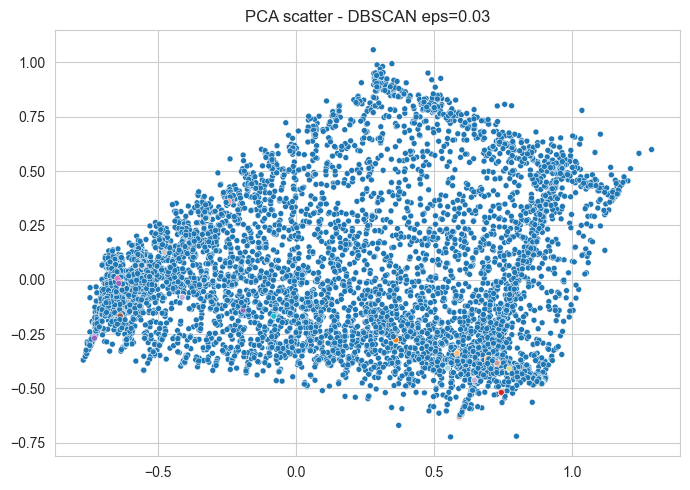

In [59]:
# DBSCAN
results_dbscan = []
eps_list = [0.03, 0.05, 0.08, 0.1]

for eps in eps_list:
    t0 = time.time()
    db = DBSCAN(eps=eps, min_samples=5).fit(X)
    t1 = time.time()
    labels_db = db.labels_
    n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)

    if n_clusters >= 2:
        mask = labels_db != -1
        try:
            sil = silhouette_score(X[mask], labels_db[mask])
        except Exception:
            sil = float('nan')
        ch = calinski_harabasz_score(X[mask], labels_db[mask]) if len(set(labels_db[mask])) > 1 else float('nan')
        dbs = davies_bouldin_score(X[mask], labels_db[mask]) if len(set(labels_db[mask])) > 1 else float('nan')
    else:
        sil = float('nan')
        ch = float('nan')
        dbs = float('nan')

    results_dbscan.append({
        'algorithm': 'DBSCAN',
        'params': f'eps={eps}',
        'n_clusters': n_clusters,
        'silhouette': sil,
        'calinski_harabasz': ch,
        'davies_bouldin': dbs,
        'runtime_s': t1 - t0,
    })

dbscan_df = pd.DataFrame(results_dbscan)
dbscan_df.to_csv('Output/dbscan_metrics.csv', index=False)
print('Saved Output/dbscan_metrics.csv')
print(dbscan_df)

valid_dbscan = dbscan_df['silhouette'].notna()
if valid_dbscan.any():
    best_db_row = dbscan_df.loc[dbscan_df['silhouette'].idxmax()]
else:
    best_db_row = dbscan_df.iloc[0]

print('Best DBSCAN by silhouette:')
print(best_db_row)

best_eps = float(best_db_row['params'].split('=')[1])
best_db_labels = DBSCAN(eps=best_eps, min_samples=5).fit_predict(X)

plt.figure(figsize=(7, 5))
sbn.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=best_db_labels, palette='tab20', s=18, legend=False)
plt.title(f'PCA scatter - DBSCAN eps={best_eps}')
plt.tight_layout()
plt.savefig('Output/compare_best_DBSCAN.png', dpi=150, bbox_inches='tight')
plt.show()

In [60]:
# Bảng so sánh chung SOM, KMeans và DBSCAN
summary_rows = []

summary_rows.append({
    'algorithm': 'SOM',
    'params': f'k={best_k}',
    'n_clusters': len(np.unique(labels)),
    'silhouette': silhouette_score(X, labels),
    'calinski_harabasz': calinski_harabasz_score(X, labels),
    'davies_bouldin': davies_bouldin_score(X, labels),
    'runtime_s': np.nan,
})

best_km_summary = kmeans_df.loc[kmeans_df['silhouette'].idxmax()]
summary_rows.append({
    'algorithm': 'KMeans',
    'params': best_km_summary['params'],
    'n_clusters': int(best_km_summary['n_clusters']),
    'silhouette': float(best_km_summary['silhouette']),
    'calinski_harabasz': float(best_km_summary['calinski_harabasz']),
    'davies_bouldin': float(best_km_summary['davies_bouldin']),
    'runtime_s': float(best_km_summary['runtime_s']),
})

best_db_summary = dbscan_df.loc[dbscan_df['silhouette'].idxmax()]
summary_rows.append({
    'algorithm': 'DBSCAN',
    'params': best_db_summary['params'],
    'n_clusters': int(best_db_summary['n_clusters']),
    'silhouette': float(best_db_summary['silhouette']),
    'calinski_harabasz': float(best_db_summary['calinski_harabasz']),
    'davies_bouldin': float(best_db_summary['davies_bouldin']),
    'runtime_s': float(best_db_summary['runtime_s']),
})

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv('Output/clustering_summary.csv', index=False)
print('Saved Output/clustering_summary.csv')
print(summary_df)

Saved Output/clustering_summary.csv
  algorithm    params  n_clusters  silhouette  calinski_harabasz  \
0       SOM       k=2           2    0.370307        5909.740811   
1    KMeans       k=2           2    0.386742        6191.000866   
2    DBSCAN  eps=0.03          55    0.444151        4865.969426   

   davies_bouldin  runtime_s  
0        1.123979        NaN  
1        1.111859   0.089087  
2        0.546089   0.590039  


### Lưu & nạp lại mô hình

In [61]:
## Lưu mô hình
bundle = {
    'som': som,
    'scaler': scaler,
    'kmeans': kmeans,
    'weight_labels': weight_labels
}
jlb.dump(bundle, 'Output/SOM_CC_GENERAL.mdl')
print('** Đã lưu mô hình: Output/SOM_CC_GENERAL.mdl')

** Đã lưu mô hình: Output/SOM_CC_GENERAL.mdl


In [62]:
## Nạp lại mô hình
bundle_loaded = jlb.load('Output/SOM_CC_GENERAL.mdl')
print('** Các khóa trong bundle đã nạp lại:')
print(bundle_loaded.keys())

** Các khóa trong bundle đã nạp lại:
dict_keys(['som', 'scaler', 'kmeans', 'weight_labels'])


Kết luận
- SOM giúp giảm chiều và phân cụm dữ liệu theo lưới 2D.
- Gom cụm trên SOM cho phép nhìn nhanh các nhóm khách hàng.
- Silhouette score chỉ mang tính tham khảo cho bài toán không giám sát.